# Using CLERO samples

`emu.sample` returns samples from CLERO's climate distribution: complete climates with spatially coherent fields, sample axis first. Any quantity computed from one climate can be computed from every sample, and the spread across samples is CLERO's uncertainty on that quantity.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from clero import Emulator
from clero.climate_analysis import global_mean, latitude_centers, latitude_weights

INPUTS = {
    "T_star": 3000.0, "F_star": 1000.0, "radius": 1.0, "gravity": 9.8,
    "P_rot": 10.0, "P0": 1.0, "CO2": 4.0e-4, "CH4": 0.0, "GCM": "um",
}
emu = Emulator()
lat = latitude_centers(emu.grid_shape[0])

## Uncertainty on a derived quantity

We compute the area-weighted global-mean surface temperature of each of 256 samples; the mean and standard deviation of the 256 values are CLERO's estimate and uncertainty for that quantity. The second cell repeats this for the maximum zonal-mean eastward wind over the five lowest levels.

In [2]:
samples = emu.sample(INPUTS, n_samples=256, seed=0)
global_means = np.array([global_mean(s, lat) for s in samples["surface_temperature"]])
print(f"global-mean surface T: {global_means.mean():.2f} ± {global_means.std(ddof=1):.2f} K")

global-mean surface T: 242.15 ± 5.74 K


In [3]:
# A wind diagnostic: the strongest zonal-mean eastward wind over the five lowest levels.
u_fields = [f"u_{i}" for i in range(10)]
wind_samples = emu.sample(INPUTS, fields=u_fields, n_samples=128, seed=1)
u_levels = np.stack([wind_samples[field] for field in u_fields], axis=1)  # (sample, level, lat, lon)
max_zonal_mean_zonal_wind = u_levels[:, :5].mean(axis=-1).max(axis=(1, 2))
print(
    "max zonal-mean zonal wind: "
    f"{max_zonal_mean_zonal_wind.mean():.2f} ± {max_zonal_mean_zonal_wind.std(ddof=1):.2f} m/s"
)


max zonal-mean zonal wind: 33.00 ± 2.99 m/s


## Per-cell uncertainty: analytic variance versus samples

`predict(..., return_variance=True)` returns the variance of each field at every grid cell without sampling. For each instellation we take the per-cell standard deviation of surface temperature from the analytic variance and from 1,024 samples, and average each over the map. The two curves agree to within sampling noise. Both are per-cell quantities; neither is the uncertainty of the global mean.

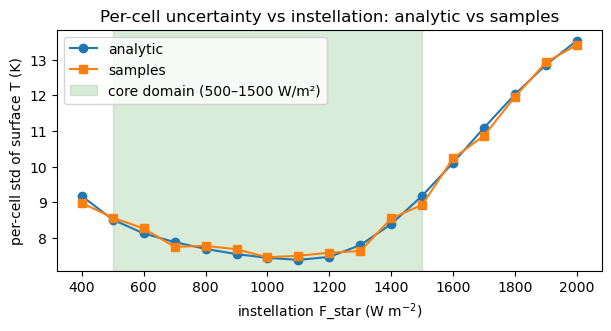

In [ ]:
# Per-cell std of surface temperature vs instellation: analytic variance vs samples, averaged over the map.
fluxes = np.arange(400.0, 2000.0 + 1.0, 100.0)  # inside the extended domain (400–3100 W/m²)
flux_batch = [{**INPUTS, "F_star": float(f_star)} for f_star in fluxes]
w = latitude_weights(lat)

_, variance = emu.predict(flux_batch, fields=["surface_temperature"], space="model", return_variance=True)
analytic_std = (np.sqrt(variance["surface_temperature"]).mean(axis=2) * w[None]).sum(axis=1)

surface_samples = emu.sample(flux_batch, fields=["surface_temperature"], n_samples=1024, seed=2, space="model", batch_size=1)["surface_temperature"]
sample_std = (surface_samples.std(axis=0, ddof=1).mean(axis=2) * w[None]).sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(fluxes, analytic_std, marker="o", label="analytic")
ax.plot(fluxes, sample_std, marker="s", label="samples")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="per-cell std of surface T (K)",
    title="Per-cell uncertainty vs instellation: analytic vs samples",
)
ax.legend()
plt.show()


## Uncertainty on the global mean

The global mean is a weighted sum over cells, so its uncertainty depends on how the errors in different cells are correlated: errors correlated across the map add, independent errors largely cancel. The per-cell variance carries no information about this correlation. For temperature, the global mean also has an analytic Gaussian distribution if the covariance is included; here we use samples. We apply `global_mean` to each sample and take the standard deviation of the results; it is smaller than the per-cell standard deviation.

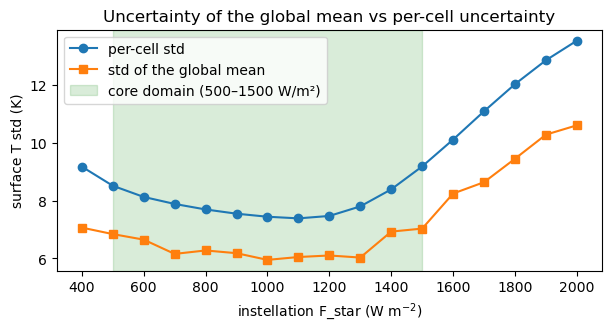

In [ ]:
# Std of the global-mean surface temperature across samples. Surface temperature is not transformed,
# so model space and physical units coincide and the model-space samples above can be reused.
global_means = np.array([[global_mean(s, lat) for s in per_flux] for per_flux in surface_samples.swapaxes(0, 1)])  # (flux, sample)
scalar_std = global_means.std(axis=1, ddof=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(fluxes, analytic_std, marker="o", label="per-cell std")
ax.plot(fluxes, scalar_std, marker="s", label="std of the global mean")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="surface T std (K)",
    title="Uncertainty of the global mean vs per-cell uncertainty",
)
ax.legend()
plt.show()


## Global-mean surface temperature with an uncertainty band

Quantiles of the per-sample global means give a central estimate (the median) and uncertainty bands (16th–84th percentiles, roughly 1σ; 2.5th–97.5th, roughly 2σ) as a function of instellation. The bands widen outside the core domain, where training simulations are sparser.

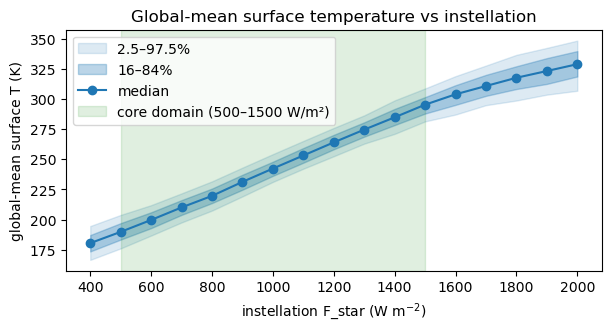

In [ ]:
# Quantiles of the per-sample global means (flux, sample) across the sample axis.
lo2, lo1, med, hi1, hi2 = np.quantile(global_means, [0.025, 0.16, 0.5, 0.84, 0.975], axis=1)

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.fill_between(fluxes, lo2, hi2, alpha=0.15, color="C0", label="2.5–97.5%")
ax.fill_between(fluxes, lo1, hi1, alpha=0.30, color="C0", label="16–84%")
ax.plot(fluxes, med, color="C0", marker="o", label="median")
ax.axvspan(500.0, 1500.0, alpha=0.12, color="green", label="core domain (500–1500 W/m²)")
ax.set(
    xlabel="instellation F_star (W m$^{-2}$)",
    ylabel="global-mean surface T (K)",
    title="Global-mean surface temperature vs instellation",
)
ax.legend()
plt.show()


## Summarizing humidity and cloud fraction

Specific humidity and cloud fraction can be strongly skewed in physical units, so a physical-space mean ± standard deviation can extend below zero. Here we estimate humidity's 16th, 50th and 84th percentiles at each location in model space, then convert them with `to_physical`. This gives a median and an asymmetric interval in kg/kg (see [UNCERTAINTY.md](../UNCERTAINTY.md)). For comparison, we also compute the physical-space mean ± standard deviation at each location, using the same samples. The printed values are area averages of these per-cell summaries, not percentiles or uncertainty bounds of the global mean.

In [ ]:
field = "specific_humidity_5"
lnq = emu.sample(INPUTS, n_samples=256, seed=0, space="model", fields=[field])[field]   # model space is ln(q)
bounds = emu.to_physical(field, np.quantile(lnq, [0.16, 0.5, 0.84], axis=0), INPUTS)
lo, med, hi = [global_mean(bound, lat) for bound in bounds]
print(f"Area-averaged per-cell 16th / 50th / 84th percentiles: {lo:.2e} / {med:.2e} / {hi:.2e} kg/kg")

q = emu.to_physical(field, lnq, INPUTS)
mu, sd = q.mean(axis=0), q.std(axis=0, ddof=1)
lo, central, hi = [global_mean(bound, lat) for bound in [mu - sd, mu, mu + sd]]
print(f"Area-averaged per-cell mean - std / mean / mean + std: {lo:.2e} / {central:.2e} / {hi:.2e} kg/kg")
print(f"Fraction of planet with mean - std below zero: {global_mean((mu - sd < 0).astype(float), lat):.0%}")


Area-averaged per-cell 16th / 50th / 84th percentiles: 1.24e-04 / 2.52e-04 / 5.08e-04 kg/kg
Area-averaged per-cell mean - std / mean / mean + std: 6.62e-05 / 3.23e-04 / 5.79e-04 kg/kg
Fraction of planet with mean - std below zero: 36%


## Requesting a subset of fields

`fields=[...]` restricts computation and output to the named fields. With many samples this matters for memory: 256 samples of all 53 fields is 256 × 53 maps of 32 × 64.

In [8]:
surface_only = emu.sample(INPUTS, fields=["surface_temperature"], n_samples=256)
print("returned fields:", list(surface_only))
print("shape:", surface_only["surface_temperature"].shape)

returned fields: ['surface_temperature']
shape: (256, 32, 64)


## Many planets at once

`sample` accepts a batch of planets, as a list of input dicts or a dict of arrays, and returns arrays with a planet axis after the sample axis; the instellation sweep above is one example. `batch_size` trades memory for speed. With a CUDA GPU, `Emulator(device="cuda")` runs the same call on the GPU.